# Analisis Data Konten Netflix: Eksplorasi Tren dan Pola

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_csv("netflix_titles.csv")
print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

### Penjelasan struktur data awal



In [19]:
print("Ukuran dataset:", df.shape)
df.info()
print(df.describe())

Ukuran dataset: (8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
       release_year
count   8807.000000
mean    2014.180198
std        8.819312
min     1925.000000
25%     2013.000000
50%     2017.000000
75%     2019.000000
max     2021.000000


### Pemeriksaan kualitas data

In [20]:
print("Missing Value:")
print(df.isna().sum().sort_values(ascending=False))
print("Duplicate:", df.duplicated().sum())

Missing Value:
director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64
Duplicate: 0


### Pembersihan data

Menangani nilai yang hilang di kolom tertentu dengan mengisi 'Unknown' dan mengonversi kolom date_added ke tipe datetime.

In [21]:
cols = ["director", "cast", "country", "rating", "duration"]
df[cols] = df[cols].fillna("Unknown")
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")
print("Missing Value Setelah Cleaning:")
print(df.isna().sum().sort_values(ascending=False))

Missing Value Setelah Cleaning:
date_added      98
show_id          0
title            0
type             0
director         0
cast             0
country          0
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64


### Analisis distribusi tipe konten



Jumlah Movie dan TV Show:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64
Persentase:
type
Movie      69.62
TV Show    30.38
Name: proportion, dtype: float64


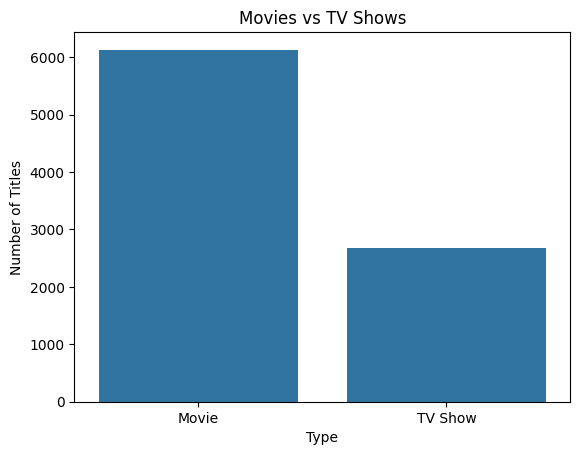

In [22]:
type_count = df["type"].value_counts()
print("Jumlah Movie dan TV Show:")
print(type_count)
print("Persentase:")
print(df["type"].value_counts(normalize=True).mul(100).round(2))
sns.countplot(data=df, x="type")
plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Number of Titles")
plt.show()

### Analisis konten berdasarkan tahun rilis

Menampilkan 10 tahun teratas dengan konten terbanyak.

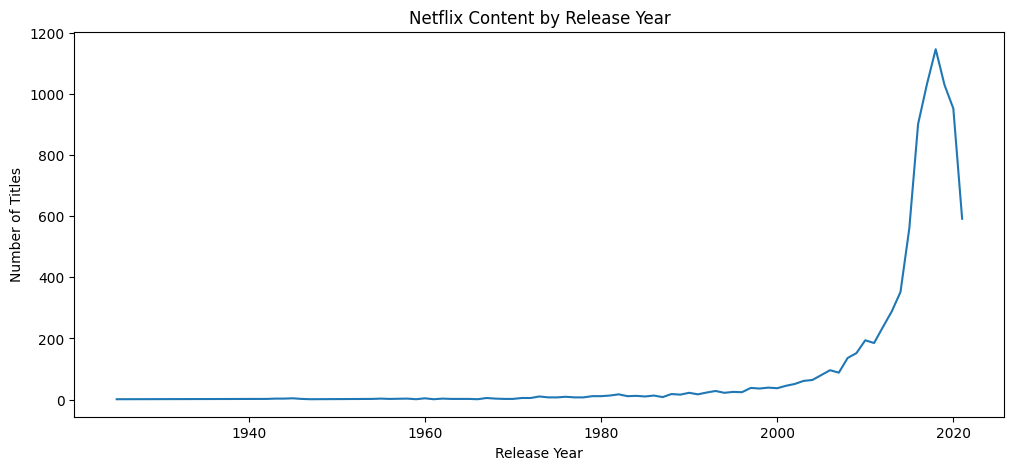

Top 10 Release Years:
release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
2021     592
2015     560
2014     352
2013     288
2012     237
Name: count, dtype: int64


In [23]:
year_count = df["release_year"].value_counts().sort_index()
year_count.plot(figsize=(12, 5))
plt.title("Netflix Content by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()
print("Top 10 Release Years:")
print(df["release_year"].value_counts().head(10))

### Analisis rating konten teratas

Mengidentifikasi dan memvisualisasikan 10 rating konten yang paling sering muncul.

Top Ratings:
rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64


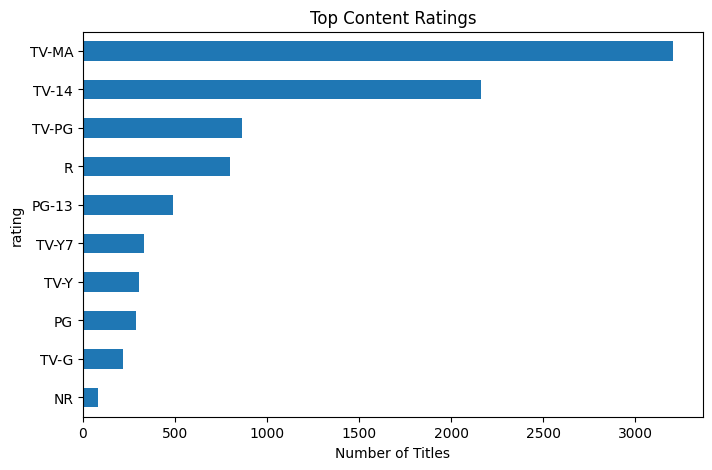

In [24]:
rating_count = df["rating"].value_counts().head(10)
print("Top Ratings:")
print(rating_count)
rating_count.sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)
plt.title("Top Content Ratings")
plt.xlabel("Number of Titles")
plt.show()

### Analisis negara penghasil konten teratas

Menentukan dan memvisualisasikan 10 negara yang paling banyak menyumbangkan konten ke Netflix.

Top 10 Countries:
country
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64


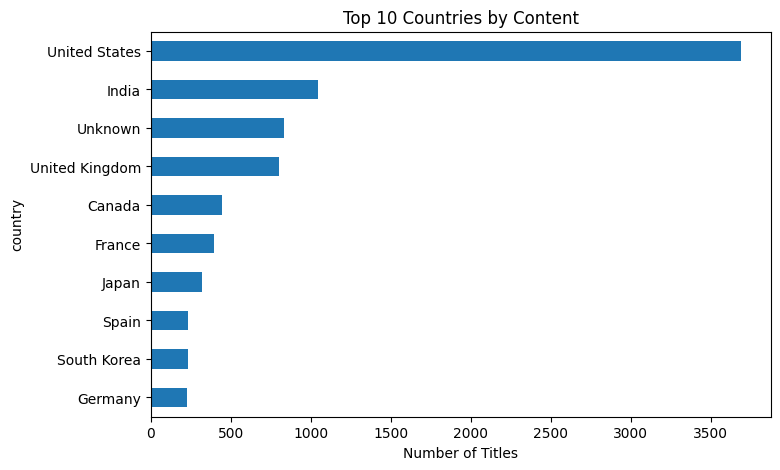

In [25]:
countries = df["country"].str.split(", ").explode()
top_countries = countries.value_counts().head(10)
print("Top 10 Countries:")
print(top_countries)
top_countries.sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)
plt.title("Top 10 Countries by Content")
plt.xlabel("Number of Titles")
plt.show()

### Analisis genre konten teratas

Mencari dan memvisualisasikan 10 genre konten yang paling populer di Netflix.

Top 10 Genres:
listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


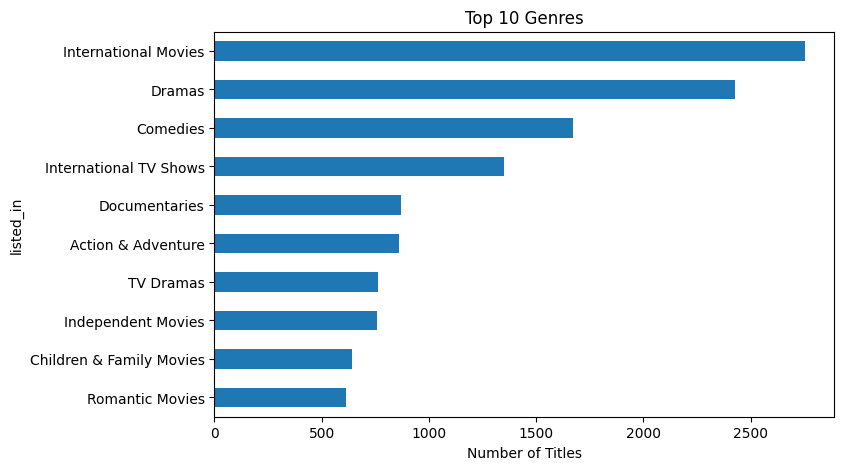

In [26]:
genres = df["listed_in"].str.split(", ").explode()
top_genres = genres.value_counts().head(10)
print("Top 10 Genres:")
print(top_genres)
top_genres.sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)
plt.title("Top 10 Genres")
plt.xlabel("Number of Titles")
plt.show()

### Analisis tren penambahan konten per tahun

Melihat tren kapan konten ditambahkan ke platform Netflix dari waktu ke waktu.

Content Added by Year:
added_year
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64


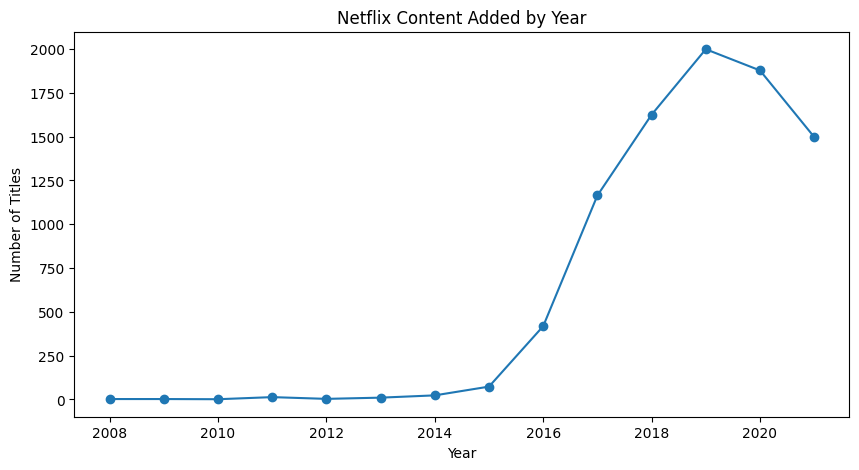

In [27]:
df["added_year"] = df["date_added"].dt.year
added = df["added_year"].value_counts().sort_index()
print("Content Added by Year:")
print(added)
added.plot(
    kind="line",
    marker="o",
    figsize=(10, 5)
)
plt.title("Netflix Content Added by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

### Analisis distribusi durasi film

Memfilter dataset untuk film, mengekstrak durasinya dalam menit, dan memvisualisasikan distribusinya.

Movie Duration:
count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_min, dtype: float64


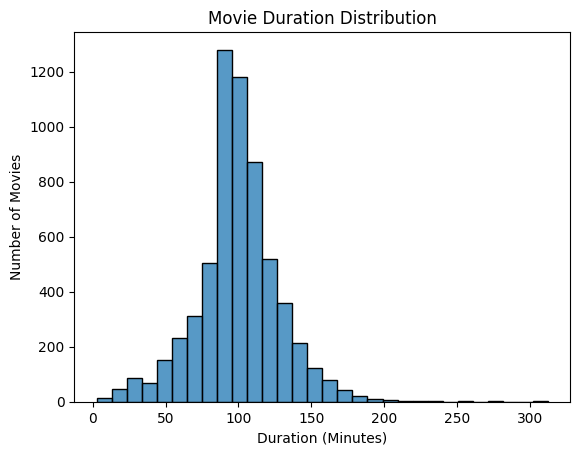

In [28]:
movies = df[df["type"] == "Movie"].copy()
movies["duration_min"] = (
    movies["duration"]
    .str.extract(r"(\d+)")
    .astype(float)
)
print("Movie Duration:")
print(movies["duration_min"].describe())
sns.histplot(
    movies["duration_min"].dropna(),
    bins=30
)
plt.title("Movie Duration Distribution")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")
plt.show()

### Perbandingan film dan serial TV berdasarkan tahun rilis

Menganalisis dan membandingkan jumlah film dan serial TV yang dirilis setiap tahun.

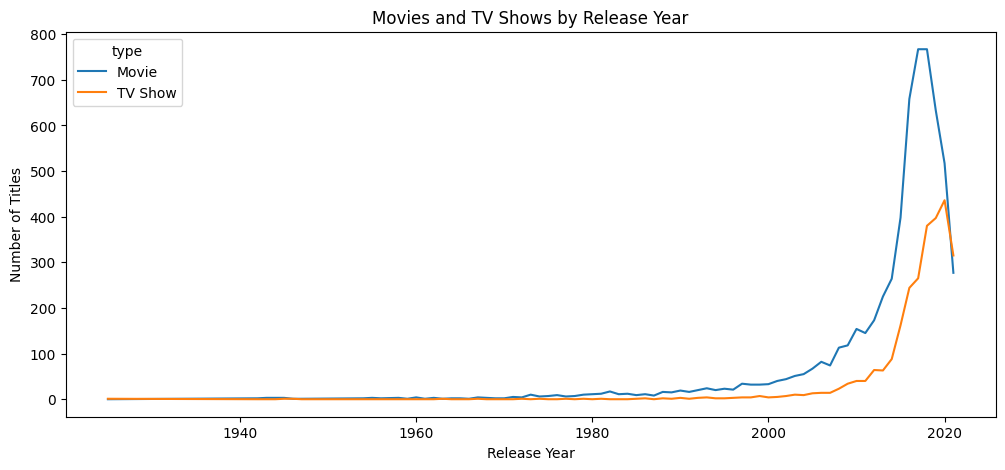

In [29]:
year_type = (
    df.groupby(["release_year", "type"])
    .size()
    .unstack(fill_value=0)
)
year_type.plot(figsize=(12, 5))
plt.title("Movies and TV Shows by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

### Ringkasan KPI (Key Performance Indicator)

Menyajikan metrik kunci dari analisis data seperti total judul, jumlah film/serial TV, negara unik, genre unik, dan rata-rata durasi film.

In [30]:
kpi = {
    "Total Titles": len(df),
    "Movies": (df["type"] == "Movie").sum(),
    "TV Shows": (df["type"] == "TV Show").sum(),
    "Countries": countries.nunique(),
    "Genres": genres.nunique(),
    "Average Movie Duration": movies["duration_min"].mean()
}
print("KPI SUMMARY")
print(pd.Series(kpi))

KPI SUMMARY
Total Titles              8807.000000
Movies                    6131.000000
TV Shows                  2676.000000
Countries                  128.000000
Genres                      42.000000
Average Movie Duration      99.577187
dtype: float64


### Ringkasan analisis berdasarkan tipe konten

Merangkum statistik penting untuk film dan serial TV secara terpisah, termasuk jumlah judul dan rata-rata tahun rilis.

In [31]:
summary = df.groupby("type").agg(
    titles=("show_id", "count"),
    avg_release_year=("release_year", "mean")
)
print("Summary berdasarkan Type:")
print(summary)

Summary berdasarkan Type:
         titles  avg_release_year
type                             
Movie      6131       2013.121514
TV Show    2676       2016.605755


### Hasil utama dan temuan kunci

Menyoroti poin-poin paling signifikan yang ditemukan dari seluruh analisis, seperti jenis konten, rating, genre, dan negara paling dominan.

In [32]:
print("===== HASIL UTAMA ====")
print("Jenis konten terbanyak:", df["type"].value_counts().idxmax())
print("Rating terbanyak:", df["rating"].value_counts().idxmax())
print("Genre terbanyak:", top_genres.index[0])
print("Negara dengan konten terbanyak:", top_countries.index[0])
print("Tahun dengan penambahan konten terbanyak:", added.idxmax())
print("Rata-rata durasi film:", round(movies["duration_min"].mean(), 2), "menit")

===== HASIL UTAMA ====
Jenis konten terbanyak: Movie
Rating terbanyak: TV-MA
Genre terbanyak: International Movies
Negara dengan konten terbanyak: United States
Tahun dengan penambahan konten terbanyak: 2019.0
Rata-rata durasi film: 99.58 menit


### Kesimpulan

Dari analisis yang telah dilakuna, terdapat beberapa poin penting:

1.  Netflix memiliki jauh lebih banyak film dibandingkan serial TV, dengan film mencakup hampir 70% dari seluruh koleksi. Ini menunjukkan bahwa netflix sangat berfokus untuk menyediakan banyak pilihan film kepada penggunanya.

2.  Jumlah konten baru yang ditambahkan ke netflix meningkat sangat cepat, terutama mencapai puncaknya pada tahun 2019. Hal ini mencerminkan upaya besar netflix untuk terus menambah dan memperbarui koleksi mereka. Penurunan setelah tahun 2019 mungkin menunjukkan adanya perubahan strategi atau dampak dari faktor lain.

3.  Peringkat konten yang paling sering ditemukan adalah TV-MA (untuk Dewasa) dan TV-14 (untuk Remaja di atas 14 tahun). Ini menandakan bahwa netflix lebih banyak menyajikan konten yang sesuai untuk penonton dewasa dan remaja.

4.  Amerika Serikat adalah negara yang paling banyak menyumbang konten di netflix. Ini menunjukkan peran besar AS dalam industri hiburan global dan pentingnya pasar AS bagi netflix. Namun, ada juga banyak konten dari negara lain seperti India dan Inggris, yang menunjukkan keberagaman global Netflix.

5.  Genre international movies dan drama adalah jenis konten yang paling banyak tersedia. Ini menandakan daya tarik universal dari cerita drama dan upaya netflix untuk melayani selera penonton di seluruh dunia dengan berbagai konten internasional.

6.  Sebagian besar film memiliki durasi sekitar 80 hingga 120 menit, dengan rata-rata paling banyak di sekitar 90-100 menit. Ini adalah durasi standar yang biasa ditemukan pada film bioskop.

7.  Data menunjukkan bahwa produksi film dan serial TV secara keseluruhan telah meningkat pesat dalam beberapa dekade terakhir, dengan peningkatan yang signifikan dari tahun 2018 hingga 2021. Hal ini sejalan dengan peningkatan produksi konten secara global.